## Kernel to load: vax_inc_geo

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib as mpl
from textwrap import wrap
import matplotlib
import random
import matplotlib.patches as mpatches
import pickle
import pycountry
import math
import warnings
warnings.simplefilter("ignore", UserWarning)
import os
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)
from matplotlib.colors import LinearSegmentedColormap


Cannot find header.dxf (GDAL_DATA is not defined)


In [2]:
notebook_dir = os.path.dirname(os.getcwd())
source_data_path=os.path.join(notebook_dir, "Common Source Data")

In [3]:
with open(os.path.join(source_data_path,'Processed Data','WAHIS data','vaccines_sorted_by_use.pickle'),'rb') as handle:
    _,_,_,top_vaccines=pickle.load(handle)
    
top_vaccines=[(i[0],i[1],i[2]) if 'Newca' not in i[1] else (i[0],'Newcastle disease',i[2]) for i in top_vaccines]

In [4]:
SHAPEFILE = os.path.join(source_data_path,'World_Countries_Map','World_Countries__Generalized_.shp')

# Read shapefile using Geopandas
geo_df = gpd.read_file(SHAPEFILE)
geo_df=geo_df.loc[:,['COUNTRY', 'ISO', 'geometry']]
geo_df.head(3)

,COUNTRY,ISO,geometry
0,Afghanistan,AF,"POLYGON ((61.27655 35.60725, 61.29638 35.62854..."
1,Albania,AL,"POLYGON ((19.57083 41.68527, 19.58195 41.69569..."
2,Algeria,DZ,"POLYGON ((4.60335 36.88791, 4.63555 36.88638, ..."


<AxesSubplot:>

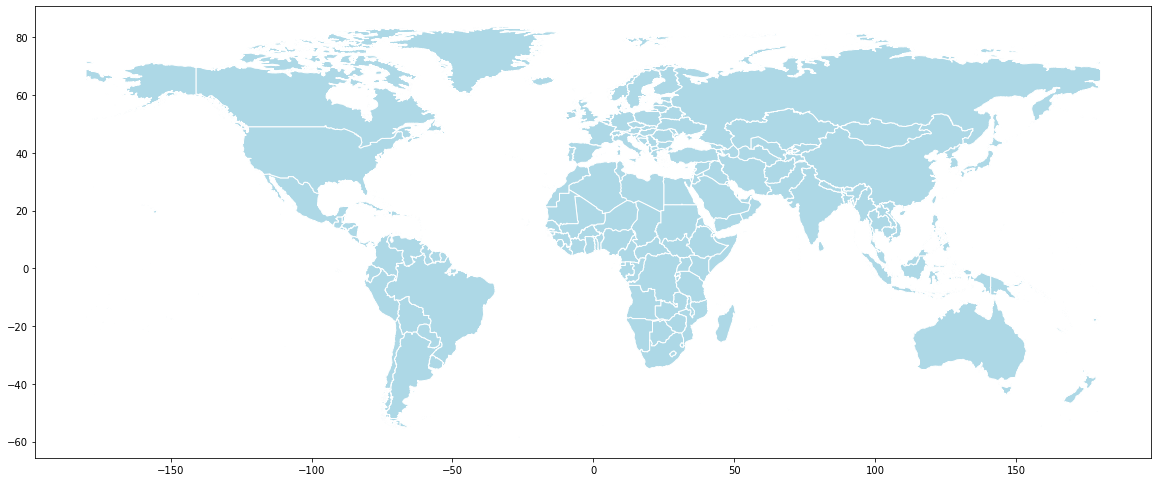

In [5]:
# Drop row for 'Antarctica'. It takes a lot of space in the map and is not of much use
geo_df = geo_df.drop(geo_df.loc[geo_df['COUNTRY'] == 'Antarctica'].index)
geo_df.reset_index(drop=True, inplace=True)

# Print the map
geo_df.plot(figsize=(20, 20), edgecolor='white', linewidth=1, color='lightblue')

In [6]:
pop_countries_geo = geo_df['ISO']

countries = {}
for country in pycountry.countries:
    countries[country.alpha_2] = country.alpha_3


codes_pop_geo = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_geo]

iso3s_pop_geo=[]

for i in pop_countries_geo:
    try:
        iso3s_pop_geo+=[countries[i]]
    except:
        iso3s_pop_geo+=[None]
        
geo_df['ISO3']=iso3s_pop_geo


print(np.unique(codes_pop_geo))

['ABW' 'AFG' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ASM' 'ATF' 'ATG'
 'AUS' 'AUT' 'AZE' 'BDI' 'BEL' 'BEN' 'BES' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS'
 'BIH' 'BLM' 'BLR' 'BLZ' 'BMU' 'BOL' 'BRA' 'BRB' 'BRN' 'BTN' 'BVT' 'BWA'
 'CAF' 'CAN' 'CCK' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG' 'COK' 'COL'
 'COM' 'CPV' 'CRI' 'CUB' 'CUW' 'CXR' 'CYM' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FLK'
 'FRA' 'FRO' 'FSM' 'GAB' 'GBR' 'GEO' 'GGY' 'GHA' 'GIB' 'GIN' 'GLP' 'GMB'
 'GNB' 'GNQ' 'GRC' 'GRD' 'GRL' 'GTM' 'GUF' 'GUM' 'GUY' 'HMD' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IMN' 'IND' 'IOT' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA'
 'JAM' 'JEY' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LIE' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAF'
 'MAR' 'MCO' 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNE'
 'MNG' 'MNP' 'MOZ' 'MRT' 'MSR' 'MTQ' 'MUS' 'MWI' 'MYS' 'MYT' 'NAM' 'NCL'
 'NER' 'NFK' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'N

In [7]:
import sys
notebook_dir = os.path.dirname(os.getcwd())
source_data_path=os.path.join(notebook_dir, "Common Source Data")
sys.path.append(source_data_path)
from country_codes import countries
from country_regions import regions
from country_regions import region_iso3
from country_regions import iso3_region


In [8]:
full_df = pd.read_csv('Supplementary Spreadsheet- Vaccination Coverage Estimates.csv')

df_2010 = full_df[full_df['Year'] == 2010]
df_2025 = full_df[full_df['Year'] == 2025]

cols = [
    'ISO3',
    'Animal',
    'Disease',
    'Vaccination Coverage (%)',
    'Official Vaccination Measure',
    'Source',
    'Year Data'
]
df_2010_sel = df_2010[cols]
df_2025_sel = df_2025[cols]

merged = pd.merge(
    df_2010_sel,
    df_2025_sel,
    on=['ISO3', 'Animal', 'Disease'],
    suffixes=('_2010', '_2025')
)

# Calculate the change
merged['Change in vaccination coverage (%)'] = (
    merged['Vaccination Coverage (%)_2025'] 
    - merged['Vaccination Coverage (%)_2010']
)

df_change = merged[
    [
        'ISO3',
        'Animal',
        'Disease',
        'Official Vaccination Measure_2010',
        'Official Vaccination Measure_2025',
        'Change in vaccination coverage (%)',
        'Source_2010',
        'Source_2025',
        'Year Data_2010',
        'Year Data_2025'
    ]
]



In [14]:
# df_change.to_csv('change_vaccination_2010_to_2025.csv',index=False)

In [15]:
def assign_category(value, categories):
    if categories[0] <= value <= categories[1]:
        return 0
    elif categories[1] < value <= categories[2]:
        return 0.25
    elif categories[2] < value <= categories[3]:
        return 0.5
    elif categories[3] < value <= categories[4]:
        return 0.75
    elif categories[4] < value <= 100:
        return 1
    else:
        return None 



In [16]:
#Function to map Category Vaccination values to specific colors in category_colors
def get_category_color(val):
    return category_colors.get(val, 'white')  # Default to white if value is not in category, will dotted hatch over missing

Poultry Newcastle disease


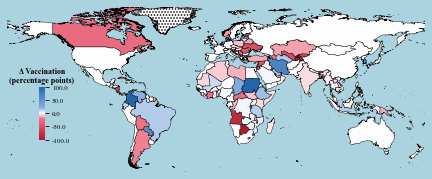

Poultry Infectious bursal disease (Gumboro disease)


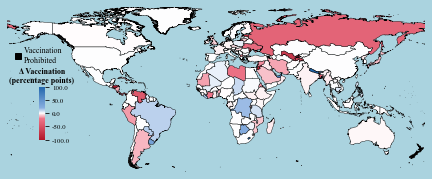

Cattle Anthrax


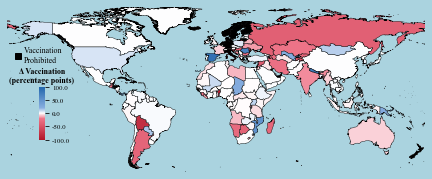

Poultry Avian infectious bronchitis


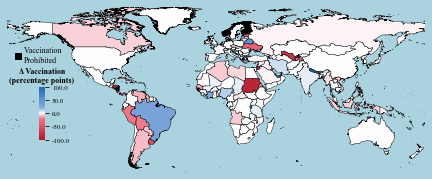

Poultry Marek's disease (-2011)


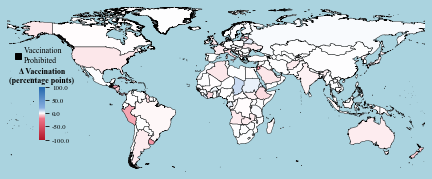

Cattle Rabies virus (Inf. with)


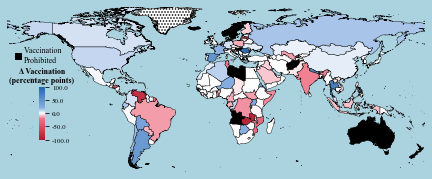

Cattle Foot and mouth disease virus (Inf. with)


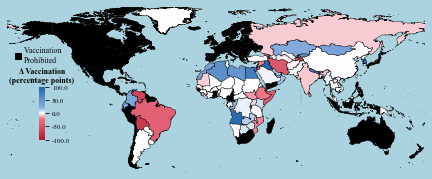

Cattle Lumpy skin disease virus (Inf. with)


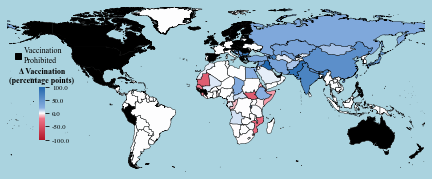

Cattle Brucella abortus (Inf. with)


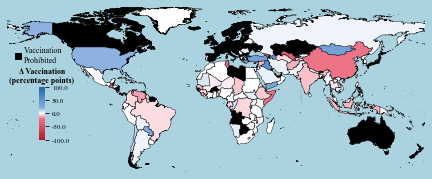

Poultry Avian infectious laryngotracheitis


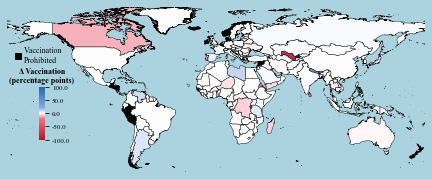

Pigs Classical swine fever virus (Inf. with)


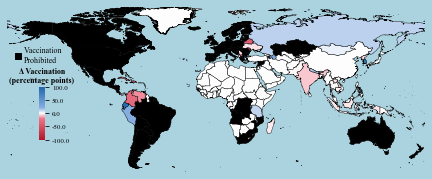

Pigs Anthrax


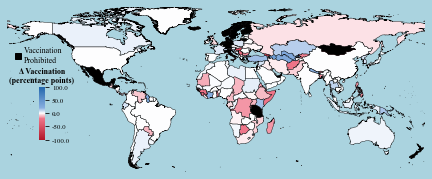

Pigs Rabies virus (Inf. with)


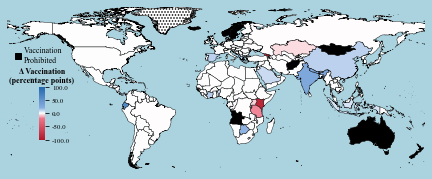

In [17]:
    plt.rcParams["font.family"] = "Times New Roman"
    background_color = (170/255, 211/255, 223/255)
    
    outdir = "2010-2025 change vaccinated maps"
    os.makedirs(outdir, exist_ok=True)
    
    animals = [i[0] for i in top_vaccines]
    animals = ['Pigs' if i=='Swine' else i for i in animals]
    vaccines = [i[1] for i in top_vaccines]
    
    for animal, disease in zip(animals[0:10] + animals[14:17],
                               vaccines[0:10] + vaccines[14:17]):
    
        plot_df = df_change[
            (df_change['Animal'] == animal) &
            (df_change['Disease'] == disease)
        ]
        merged_df = pd.merge(geo_df, plot_df, on='ISO3', how='left')
    
        # Missing / prohibited
        prohibited_df = merged_df[
            merged_df['Official Vaccination Measure_2025'] == "Vaccination prohibited"
        ]
        missing_df = merged_df[
            merged_df['Official Vaccination Measure_2025'].isna() &
            merged_df['Change in vaccination coverage (%)'].isna()
        ]
    
        # Diverging colormap
        col = 'Change in vaccination coverage (%)'
        #vmin, vmax = merged_df[col].min(), merged_df[col].max()
        vmin=-100
        vmax=100
        norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

        # deep red, pale red, light-gray at 0, pale blue, deep blue
        cmap_rbgray = LinearSegmentedColormap.from_list(
            "rb_gray",
            [
                (0.00, "#b2182b"),   # deep red
                (0.40, "#ef768a"),   # soft red
                (0.50, "#ffffff"),   
                (0.60, "#88aee0"),   # soft blue
                (1.00, "#2166ac"),   # deep blue
            ],
            N=256
        )
        cmap = cmap_rbgray#plt.cm.coolwarm
    
        # Plot
        fig, ax = plt.subplots(
            figsize=(6.31*1.3, 5.29/3*1.3),
            facecolor=background_color
        )
        ax.axis('off')
    
        merged_df.plot(
            column=col, cmap=cmap, norm=norm,
            ax=ax, edgecolor='black', linewidth=0.4,
            missing_kwds={'color': 'white'}
        )
        missing_df.plot(
            ax=ax,
            facecolor='white',       
            edgecolor='black',
            linewidth=0.2,
            hatch='....',               
            zorder=6
        )
        if not prohibited_df.empty:
            prohibited_df.plot(
                facecolor='black', edgecolor='black', linewidth=0.2,
                ax=ax, zorder=4
            )
    
        minx, miny, maxx, maxy = merged_df.total_bounds
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        ax.set_aspect('equal')
    
        # "Vaccination prohibited" legend patch
        patchNone = mpatches.Patch(edgecolor='black', facecolor='black', label='Vaccination \nProhibited')
    
        if not prohibited_df.empty:
    
            ax.legend(bbox_to_anchor=(0.152, 0.8), loc=1,
                            handles=[patchNone],fontsize=8,
                            handletextpad=0.35,
                            handleheight=.75, 
                            handlelength=.75, 
    
                            frameon=False)
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        pos = ax.get_position()
        cax = fig.add_axes([0.2, 0.195, 0.01, 0.32])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.outline.set_visible(False)
        title= cbar.ax.set_title(
            'Δ Vaccination\n(percentage points)',
            y=0.97, x=0.5,
            fontsize=8, fontweight='bold'
        )
        
        title.set_bbox({
            'boxstyle': 'round,pad=0.0',
            'facecolor': (170/255, 211/255, 223/255),
            'edgecolor': 'none',
            'alpha': 0.6
        })
        ticks = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([f"{t:.1f}" for t in ticks])
        cbar.ax.tick_params(labelsize=7)
    
        # Save
        fname = f"{animal}_{disease}"
        plt.savefig(
            f"{outdir}/{fname}.svg",
            format='svg',
            facecolor=background_color,
            bbox_inches='tight',
            pad_inches=0,
            dpi=600
        )
        plt.savefig(
            f"{outdir}/{fname}.png",
            format='png',
            facecolor=background_color,
            bbox_inches='tight',
            pad_inches=0,
            dpi=600
        )
        print(animal,disease)

        plt.show()
